<a href="https://colab.research.google.com/github/8riyaShil/Movie-Hit-o-flop-prediction/blob/main/riya_shil_movie_hit_or_flop_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv("/content/riya_shil_movie_hit_or_flop_prediction (1).csv")

In [4]:
print(df.head())
print(df.tail())

   budget_million  marketing_spend_million  num_screens  star_power_score  \
0            37.4                      NaN       1784.0               4.3   
1           207.8                     28.5       4773.0               3.8   
2           213.1                      4.5       4560.0               6.9   
3             4.4                     33.3       1657.0               4.5   
4           168.1                     48.2       4068.0               3.3   

   genre_code  runtime_minutes  critic_score  is_hit  
0         7.0            152.0           5.0       0  
1         5.0            177.0           3.0       1  
2         2.0            123.0           1.9       0  
3         4.0            114.0           3.5       0  
4         5.0            170.0           8.0       0  
      budget_million  marketing_spend_million  num_screens  star_power_score  \
1995           270.6                      4.6       2675.0               5.3   
1996           294.5                      5.4  

In [5]:
df.describe()

,budget_million,marketing_spend_million,num_screens,star_power_score,genre_code,runtime_minutes,critic_score,is_hit
count,1950.000000,1944.000000,1945.000000,1950.000000,1955.000000,1952.000000,1952.000000,2000.000000
mean,144.666154,17.591409,2632.027763,-3.582872,-8.174425,122.532787,-5.227766,0.486500
std,152.290500,91.175470,1980.014581,96.187468,108.178455,132.632224,103.732335,0.499943
min,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000
25%,78.725000,12.400000,1282.000000,3.300000,1.000000,104.000000,3.100000,0.000000
50%,153.350000,25.200000,2611.000000,5.400000,3.000000,128.000000,5.200000,0.000000
75%,228.000000,37.400000,3832.000000,7.700000,6.000000,154.000000,7.600000,1.000000
max,1360.100000,342.300000,33621.000000,70.000000,49.000000,1246.000000,59.500000,1.000000


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   budget_million           1950 non-null   float64
 1   marketing_spend_million  1944 non-null   float64
 2   num_screens              1945 non-null   float64
 3   star_power_score         1950 non-null   float64
 4   genre_code               1955 non-null   float64
 5   runtime_minutes          1952 non-null   float64
 6   critic_score             1952 non-null   float64
 7   is_hit                   2000 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 125.1 KB


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Shape: (2000, 8)

Columns:
Index(['budget_million', 'marketing_spend_million', 'num_screens',
       'star_power_score', 'genre_code', 'runtime_minutes', 'critic_score',
       'is_hit'],
      dtype='object')

Data types:
budget_million             float64
marketing_spend_million    float64
num_screens                float64
star_power_score           float64
genre_code                 float64
runtime_minutes            float64
critic_score               float64
is_hit                       int64
dtype: object

Missing values:
budget_million             50
marketing_spend_million    56
num_screens                55
star_power_score           50
genre_code                 45
runtime_minutes            48
critic_score               48
is_hit                      0
dtype: int64

Duplicate rows:
5


In [8]:
numeric_columns = df.select_dtypes(include=np.number).columns.drop("is_hit")

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
budget_million             0
marketing_spend_million    0
num_screens                0
star_power_score           0
genre_code                 0
runtime_minutes            0
critic_score               0
is_hit                     0
dtype: int64


In [9]:
print(df.shape)
print(df.describe())

(2000, 8)
       budget_million  marketing_spend_million   num_screens  \
count      2000.00000              2000.000000   2000.000000   
mean        144.88325                17.804450   2631.449500   
std         150.37997                89.898071   1952.588807   
min        -999.00000              -999.000000   -999.000000   
25%          80.07500                12.700000   1322.000000   
50%         153.35000                25.200000   2611.000000   
75%         226.52500                36.900000   3788.000000   
max        1360.10000               342.300000  33621.000000   

       star_power_score   genre_code  runtime_minutes  critic_score  \
count       2000.000000  2000.000000      2000.000000    2000.00000   
mean          -3.358300    -7.923000       122.664000      -4.97750   
std           94.987265   106.966752       131.032839     102.49179   
min         -999.000000  -999.000000      -999.000000    -999.00000   
25%            3.300000     1.000000       105.000000     

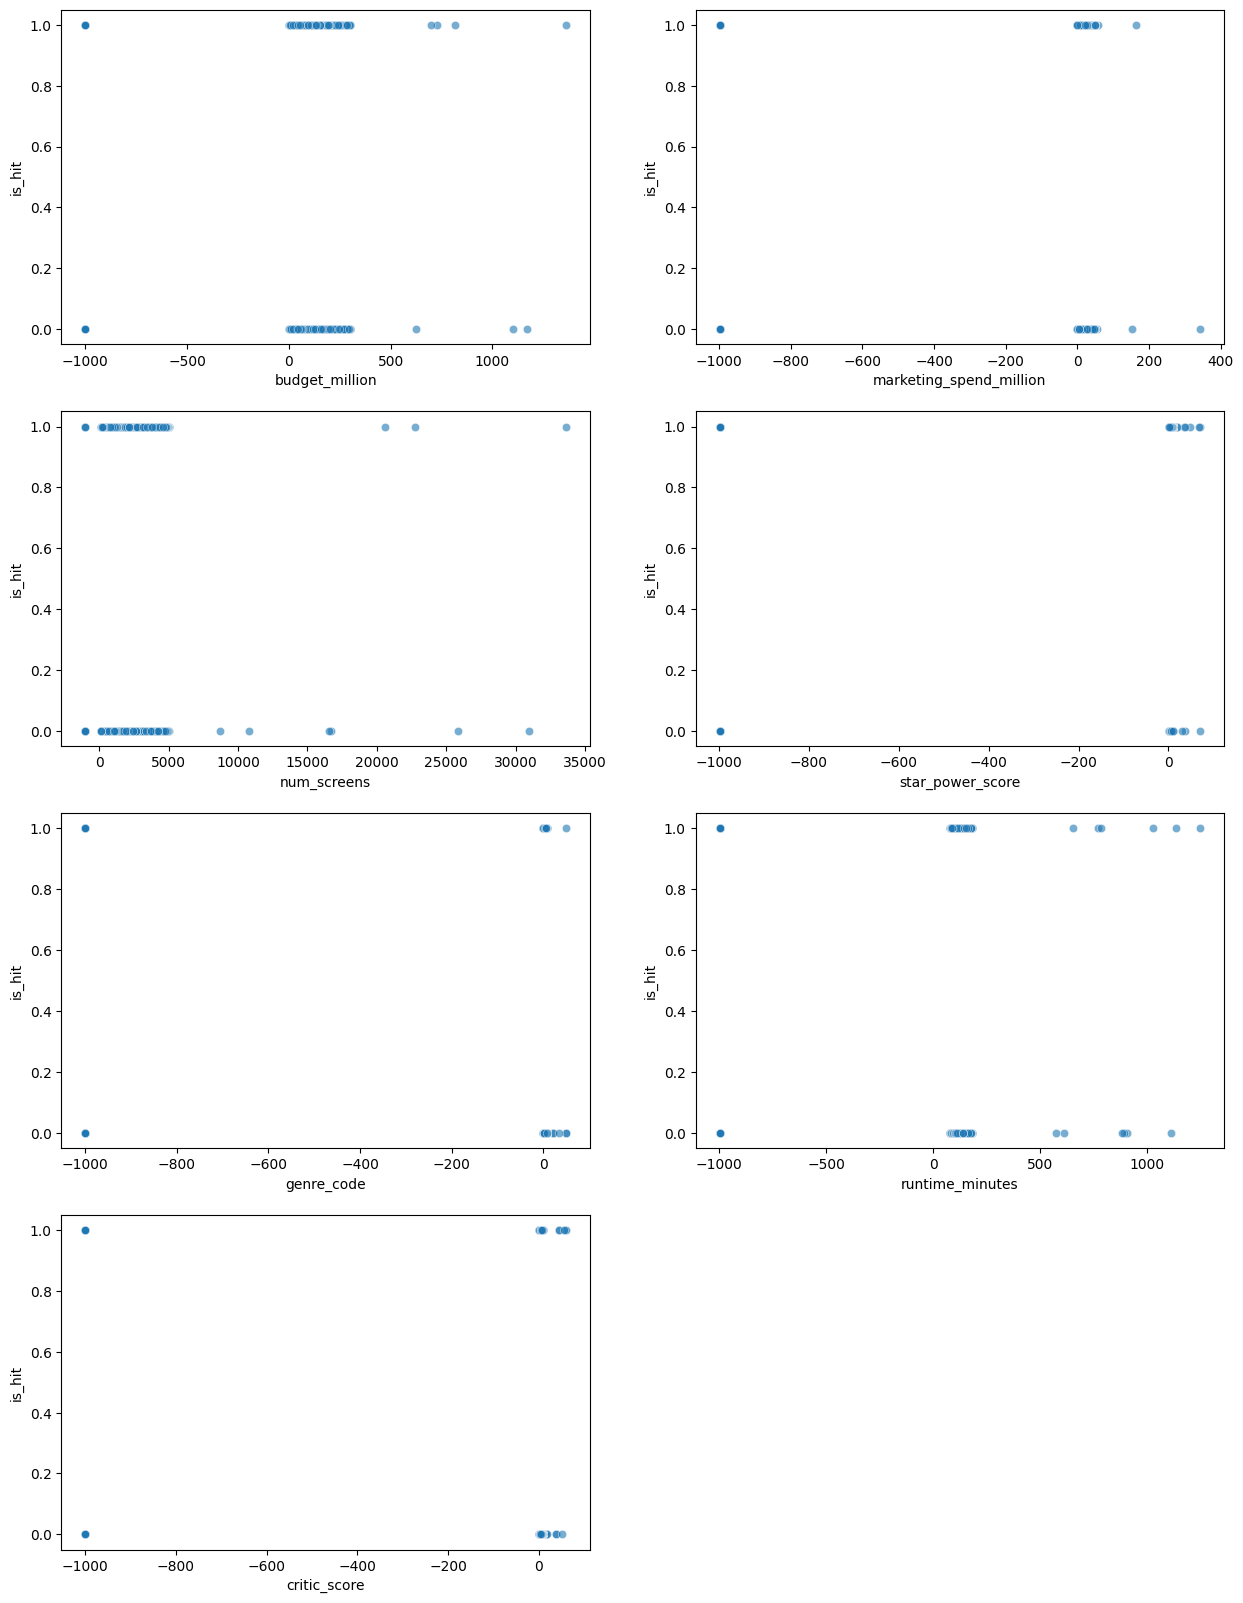

In [10]:
plt.figure(figsize=(15,20))
for i, col in enumerate(df.columns.drop('is_hit')):
    plt.subplot(4,2,i+1)
    sns.scatterplot(x=df[col],y=df['is_hit'],alpha=0.6)
plt.show()

In [11]:
original_rows = df.shape[0]

df = df[
    (df["budget_million"] >= 0) &
    (df["marketing_spend_million"] >= 0) &
    (df["num_screens"] >= 0) &
    (df["star_power_score"] >= 0) &
    (df["genre_code"] >= 0) &
    (df["runtime_minutes"] >= 0) &
    (df["runtime_minutes"] <= 300) &
    (df["critic_score"] >= 0) &
    (df["critic_score"] <= 100)
].copy()

print("Original rows:", original_rows)
print("Rows after filtering:", df.shape[0])
print("Rows removed:", original_rows - df.shape[0])

Original rows: 2000
Rows after filtering: 1860
Rows removed: 140


In [12]:
original_rows = df.shape[0]
df = df[
 (df["budget_million"] <= 500) &
 (df["marketing_spend_million"] <= 52) &
 (df["num_screens"] <= 6000) &
 (df["genre_code"] <= 20) &
 (df["star_power_score"]<=11)&
 (df["critic_score"] <= 10)

].copy()

print("Original rows:", original_rows)
print("Rows after filtering:", df.shape[0])
print("Rows removed:", original_rows - df.shape[0])

Original rows: 1860
Rows after filtering: 1816
Rows removed: 44


In [13]:
print(df["is_hit"].value_counts())

is_hit
0    934
1    882
Name: count, dtype: int64


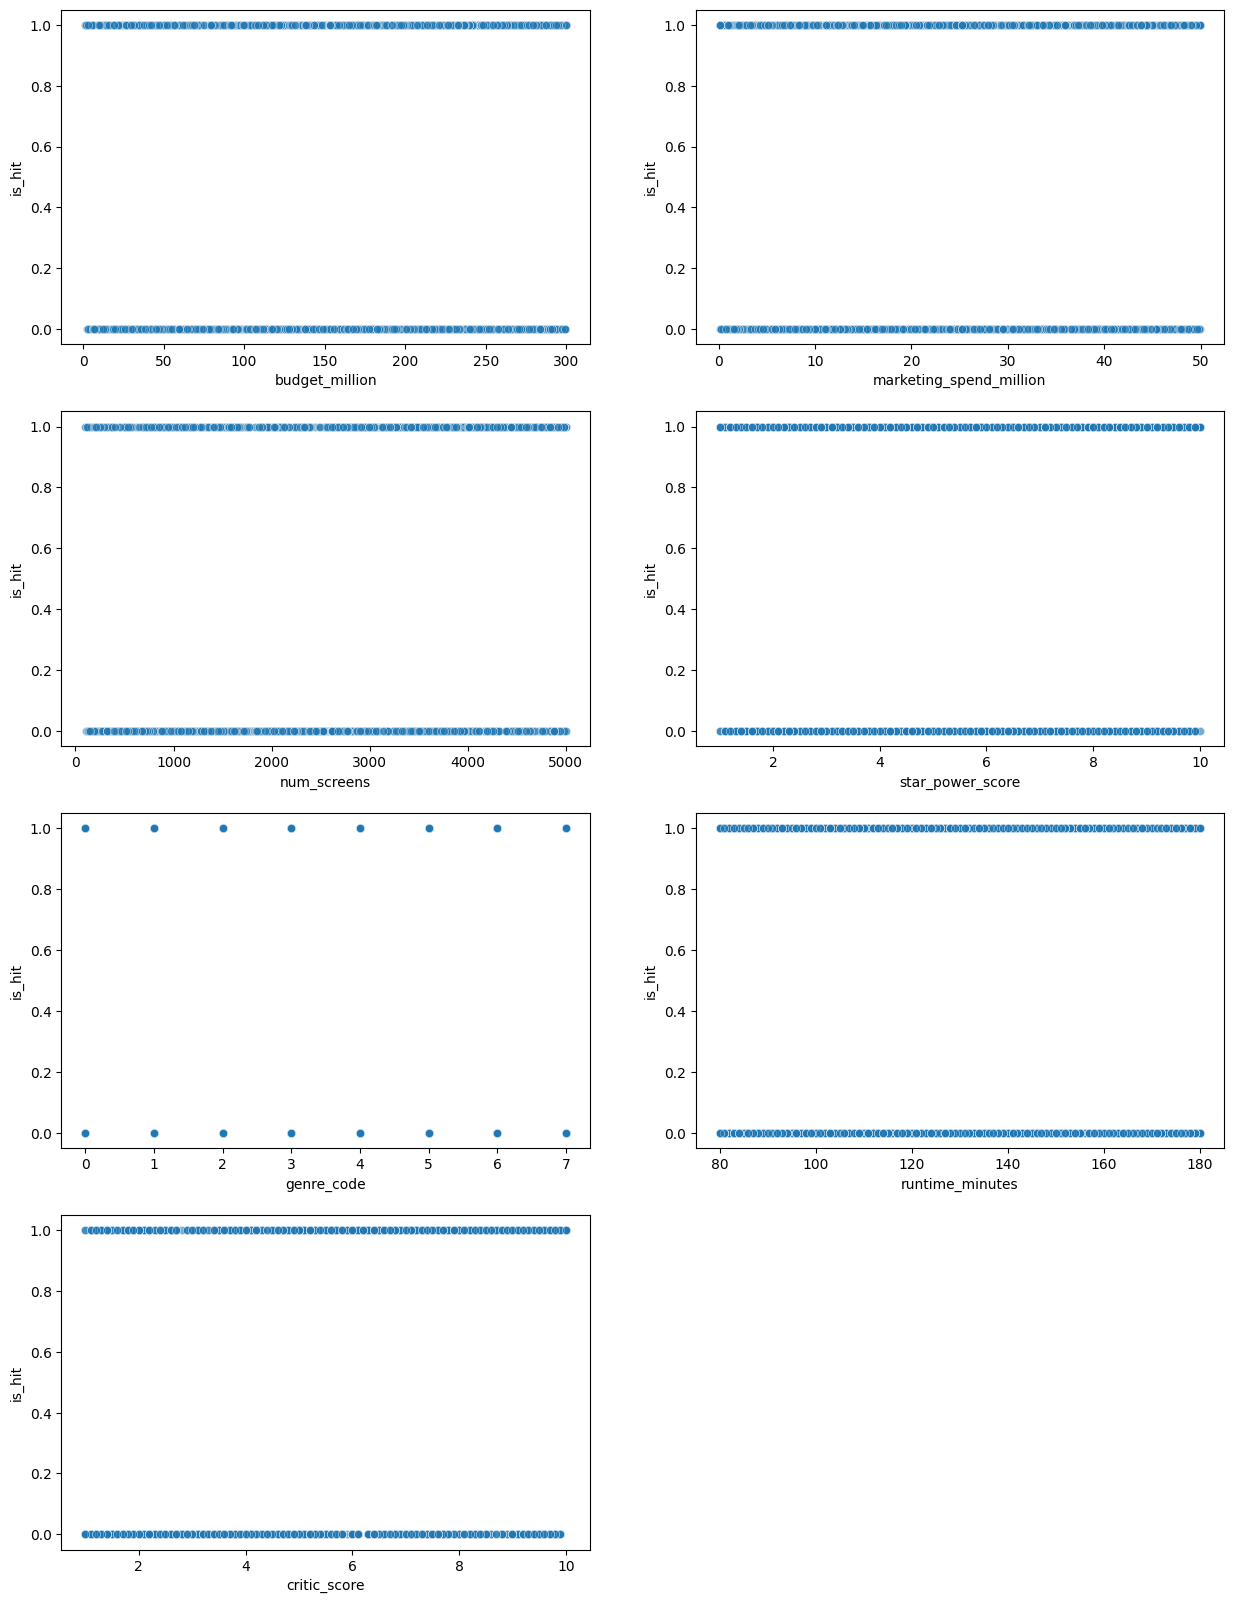

In [14]:
plt.figure(figsize=(15,20))
for i, col in enumerate(df.columns.drop('is_hit')):
    plt.subplot(4,2,i+1)
    sns.scatterplot(x=df[col],y=df['is_hit'],alpha=0.6)
plt.show()

In [15]:
df.isnull().sum()

,0
budget_million,0
marketing_spend_million,0
num_screens,0
star_power_score,0
genre_code,0
runtime_minutes,0
critic_score,0
is_hit,0


In [16]:
df = df.drop_duplicates()
print("Shape after removing duplicates values:", df.shape)

Shape after removing duplicates values: (1811, 8)


In [17]:
X = df.drop('is_hit', axis=1)
y = df['is_hit']

In [18]:
import pandas as pd # Ensure pandas is imported for DataFrame and Series

if not X.empty and not y.empty:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    print("Training data:", X_train.shape)
    print("Testing data:", X_test.shape)
else:
    print("Warning: X or y is empty. train_test_split cannot be performed.")
    # Initialize empty variables to avoid further errors in subsequent cells
    X_train, X_test, y_train, y_test = pd.DataFrame(), pd.DataFrame(), pd.Series(dtype='int64'), pd.Series(dtype='int64')

Training data: (1448, 7)
Testing data: (363, 7)


In [19]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
model = DecisionTreeClassifier(
    max_depth=4
)

# Only fit the model if X_train and y_train are not empty
if not X_train.empty and not y_train.empty:
    model.fit(X_train,y_train)
    print("Model fitted successfully.")
else:
    print("Warning: X_train or y_train is empty. Model cannot be fitted.")

Model fitted successfully.


In [20]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 1 1]


In [21]:
from sklearn.metrics import *

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.931129476584022
Accuracy percentage: 93.1129476584022 %
[[175  11]
 [ 14 163]]


In [22]:
from sklearn.metrics import classification_report

if len(y_test) > 0 and len(y_pred) > 0:
    print(classification_report(y_test, y_pred))
else:
    print("Warning: y_test or y_pred is empty. Cannot generate classification report.")

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       186
           1       0.94      0.92      0.93       177

    accuracy                           0.93       363
   macro avg       0.93      0.93      0.93       363
weighted avg       0.93      0.93      0.93       363



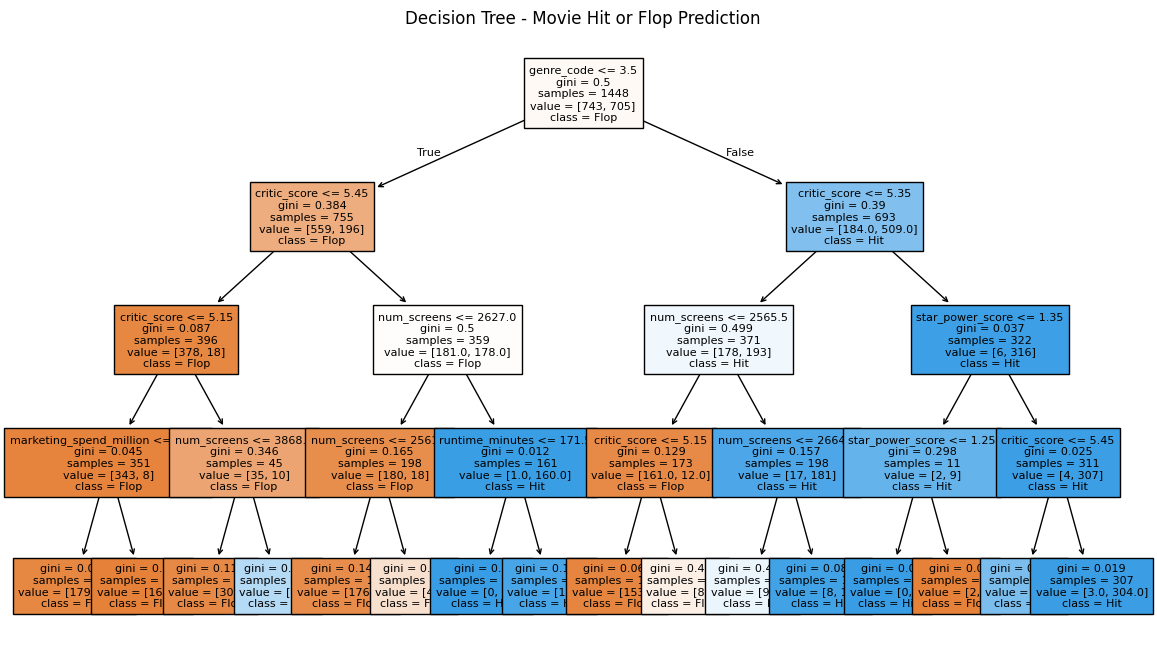

In [23]:
plt.figure(figsize=(14, 8))
if hasattr(model, 'tree_') and model.tree_ is not None:
    plot_tree(
        model,
        feature_names=X.columns,
        class_names=["Flop", "Hit"],
        filled=True,
        fontsize=8
    )
    plt.title("Decision Tree - Movie Hit or Flop Prediction")
    plt.show()
else:
    print("Warning: Model is not fitted. Cannot plot the decision tree.")

In [24]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(results.head(396))

,Actual,Predicted
518,1,1
350,0,0
959,1,1
879,0,0
1840,0,0
...,...,...
1416,0,0
433,0,0
180,0,0
740,0,0
